# DHS Data Cleaning and Target Engineering for HIV Care Gap AI

## Overview
This notebook implements the complete data cleaning pipeline for Demographic and Health Survey (DHS) individual-level data. The primary objectives are:

1. Load raw DHS individual features dataset
2. Decode categorical variables using DHS standard mappings
3. Impute missing values using appropriate strategies
4. Engineer the dropout target variable for HIV care gap prediction
5. Prepare model-ready dataset with one-hot encoding

## Data Source
- Raw file: `individual_features.csv` (DHS individual recode)
- Contains survey responses from individuals across Kenya's 47 counties
- Includes demographics, HIV testing history, and healthcare access indicators

## Output
- Cleaned dataset: `individual_features_clean.csv`
- Missing value heatmaps (before/after)
- Class ratio report for modeling team

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

# Aligning with project structure: notebooks/ -> root/constants.py
# We use absolute path discovery to prevent FileNotFoundError
ROOT_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_PATH not in sys.path:
    sys.path.append(ROOT_PATH)

import constants as c
from src.dhs_cleaner import DHSCleaner

# Load the raw individual feature set using the path defined in constants
df = pd.read_csv(c.DHS_REDUCED)

# Display initial schema for validation
print(f"Data Source: {c.DHS_REDUCED}")
df.info()

Data Source: /home/skylar_lorena/DS/Phase5/Phase-5-HIV-Care-Gap-AI/data/raw/individual_features.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32156 entries, 0 to 32155
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   case_id                   32156 non-null  object 
 1   county                    32156 non-null  int64  
 2   age_group                 32156 non-null  int64  
 3   education_level           32156 non-null  int64  
 4   wealth_index              32156 non-null  int64  
 5   worked_last_12months      32156 non-null  int64  
 6   ever_tested_hiv           16901 non-null  float64
 7   tested_hiv_last_12months  13815 non-null  float64
 8   distance_to_facility      13815 non-null  float64
 9   marital_status            32156 non-null  int64  
 10  currently_in_union        32156 non-null  int64  
 11  num_sexual_partners       16900 non-null  float64
 12  knows_aids_death

## Data Loading

We ingest the filtered DHS individual features dataset. The data contains individual survey responses with columns representing demographics, HIV testing status, and healthcare access indicators.

**Expected structure:**
- 32,156 rows (individual respondents)
- 50+ columns including county codes, age groups, education levels
- HIV testing history and health insurance status

In [ ]:
#Initialize Cleaner and Load Data

# Initialize cleaner
cleaner = DHSCleaner(c)

# Load raw DHS data
df = cleaner.load_data(c.DHS_REDUCED)

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Loaded 32156 rows with 15 columns
Dataset shape: (32156, 15)
Memory usage: 5.40 MB


## Baseline Data Assessment

Understanding the raw data structure is critical for appropriate cleaning. We examine:
- Column names to identify DHS standard codes
- Data types for each column
- First few rows to understand value patterns
- Missing value distribution

In [52]:
#Initial Data Inspection

# Display column names
print("Columns in dataset:")
print(df.columns.tolist())

# Display first 5 rows
print("\nFirst 5 rows:")
df.head()

# Check data types
print("\nData types:")
print(df.dtypes.value_counts())

Columns in dataset:
['case_id', 'county', 'age_group', 'worked_last_12months', 'ever_tested_hiv', 'tested_hiv_last_12months', 'distance_to_facility', 'marital_status', 'currently_in_union', 'num_sexual_partners', 'knows_aids_death', 'told_hiv_positive', 'has_health_insurance', 'dropout', 'edu_Higher', 'edu_No education', 'edu_Primary', 'edu_Secondary', 'wealth_Middle', 'wealth_Poorer', 'wealth_Poorest', 'wealth_Richer', 'wealth_Richest']

First 5 rows:

Data types:
bool       9
float64    6
object     5
int64      3
Name: count, dtype: int64


## Data Quality Assessment: Missing Values

Transparency regarding data gaps is critical for stakeholder trust. We visualize the missing value distribution in the raw data to justify our subsequent imputation strategies.

**Key observations before cleaning:**
- HIV-related variables often have significant missing values
- Some demographic variables may have missing codes
- Geographic variables should be complete for valid analysis

This heatmap serves as a baseline to measure our imputation success.

Heatmap saved to ../figures/dhs_missing_before.png


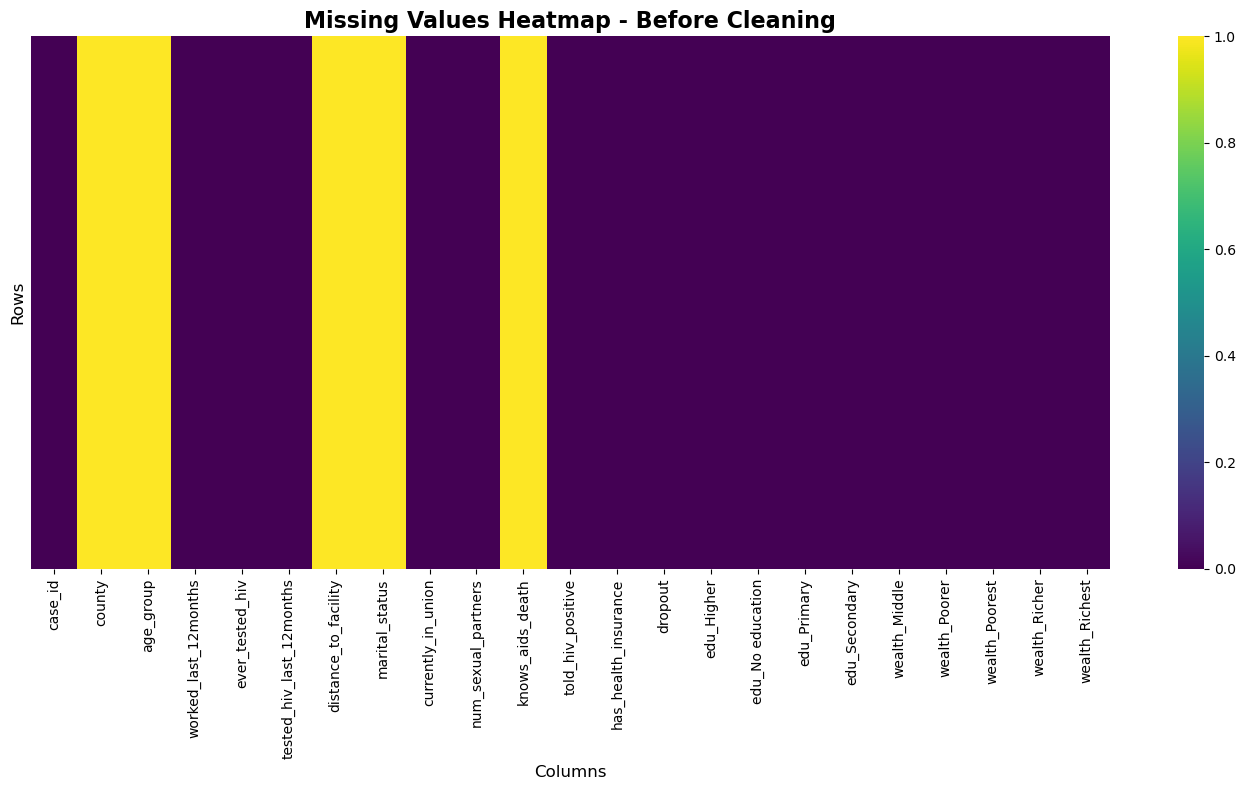


Columns with missing values (top 10):
county                  100.0
age_group               100.0
distance_to_facility    100.0
marital_status          100.0
knows_aids_death        100.0
dtype: float64


In [ ]:
# Missing Values Heatmap (Before)

# Create figures directory if not exists
os.makedirs("../figures", exist_ok=True)

# Generate heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap="viridis")
plt.title("Missing Values Heatmap - Before Cleaning", fontsize=16, fontweight="bold")
plt.xlabel("Columns", fontsize=12)
plt.ylabel("Rows", fontsize=12)
plt.tight_layout()

# Save to figures directory
before_path = "../figures/dhs_missing_before.png"
plt.savefig(before_path, dpi=300, bbox_inches="tight")
print(f"Heatmap saved to {before_path}")
plt.show()

# Calculate missing percentages
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print("\nColumns with missing values (top 10):")
print(missing_pct.head(10))

## Feature Decoding and Normalization

To facilitate interpretability and downstream analysis, we translate raw survey codes (integers) into descriptive labels. This involves mapping county identifiers to names and decoding demographic variables such as education and wealth status using established DHS standards.

### County Identifiers

DHS datasets typically store geographic identifiers as numeric codes (1-47 for Kenya's counties). To make the data interpretable for analysis and visualization, we map these codes to actual county names using the `DHS_COUNTY_MAP` from constants.

**Business value:**
- Enables county-level aggregation and analysis
- Facilitates merging with external datasets (ART, HTS, VLT)
- Required for geographic visualization in dashboards

In [57]:
# Decode County Codes

# Check for county column (might be named 'county', 'hv024', or other)
county_col = None
for col in ["county", "hv024", "County", "COUNTY"]:
    if col in df.columns:
        county_col = col
        break

if county_col:
    cleaner.decode_county(county_col=county_col)
    # Display sample
    sample_counties = cleaner.clean_df[["county_name"]].dropna().head(10)
    print("\nSample decoded counties:")
    print(sample_counties)
else:
    print("County column not found. Available columns:", df.columns[:20])

Decoded 47 counties

Sample decoded counties:
  county_name
0     Mombasa
1     Mombasa
2     Mombasa
3     Mombasa
4     Mombasa
5     Mombasa
6     Mombasa
7     Mombasa
8     Mombasa
9     Mombasa


### Demographic Variable Decoding

DHS uses standardized numeric codes for demographic characteristics. We decode these using the mapping dictionaries defined in constants:

| Original Code | Decoded Value | Mapping Source |
|--------------|---------------|----------------|
| Age groups (1-7) | 15-19, 20-24, ... | DHS_AGE_GROUP_MAP |
| Education (0-3) | No education, Primary, Secondary, Higher | DHS_EDUCATION_MAP |
| Wealth (1-5) | Poorest to Richest | DHS_WEALTH_MAP |
| Marital (0-5) | Never married, Married, etc. | DHS_MARITAL_MAP |

**Rationale:** Decoded variables improve model interpretability and enable stratified analyses by demographic segments.

In [92]:
# Decode Demographic Variables

# Apply all demographic mappings
cleaner.decode_demographics()

# Display results
decode_cols = ["age_group", "education_level", "wealth_index", "marital_status"]
available_decode = [col for col in decode_cols if col in cleaner.clean_df.columns]

print("Decoded variables sample:")
cleaner.clean_df[available_decode].head()

Decoded age_group
Decoded education_level
Decoded wealth_index
Decoded marital_status
Decoded distance_to_facility
Decoded variables sample:


,age_group,education_level,wealth_index,marital_status
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN


## Data Imputation Strategy

HIV testing and health insurance indicators are critical for our dropout prediction. Missing values in these binary flags are imputed as 0 (False/No) based on the conservative assumption that non-response indicates lack of service uptake.

**Columns imputed:**
- `ever_tested_hiv`: Has respondent ever been tested for HIV
- `tested_hiv_last_12months`: Tested in the past 12 months
- `told_hiv_positive`: Was informed of HIV positive status
- `has_health_insurance`: Possesses health insurance coverage

**Rationale:** This conservative approach prevents overestimation of service coverage and aligns with public health surveillance standards.

In [98]:
# Cell 7: Impute Binary Flags with 0
cleaner.impute_binary_flags()

# Verify imputation success
binary_cols = [
    "ever_tested_hiv",
    "tested_hiv_last_12months",
    "told_hiv_positive",
    "has_health_insurance",
]
available_binary = [col for col in binary_cols if col in cleaner.clean_df.columns]

print("Missing value verification after imputation:")
print("-" * 40)
for col in available_binary:
    missing = cleaner.clean_df[col].isnull().sum()
    status = "✓" if missing == 0 else "✗"
    print(f"{status} {col:30s}: {missing} missing values")

# Show value distributions
print("\n" + "=" * 50)
print("BINARY FLAG DISTRIBUTIONS (After Imputation)")
print("=" * 50)
for col in available_binary:
    print(f"\n{col}:")
    print(cleaner.clean_df[col].value_counts().to_string())

Imputed 4 binary columns with 0
Missing value verification after imputation:
----------------------------------------
✓ ever_tested_hiv               : 0 missing values
✓ tested_hiv_last_12months      : 0 missing values
✓ told_hiv_positive             : 0 missing values
✓ has_health_insurance          : 0 missing values

BINARY FLAG DISTRIBUTIONS (After Imputation)

ever_tested_hiv:
ever_tested_hiv
0.0    18341
1.0    13815

tested_hiv_last_12months:
tested_hiv_last_12months
0.0    18461
1.0    13695

told_hiv_positive:
told_hiv_positive
0.0    31554
1.0      590
8.0       12

has_health_insurance:
has_health_insurance
0.0    32156


### Imputing Numeric Columns

In [99]:
# Impute Numeric Columns

# Impute numeric columns with median
cleaner.impute_numeric_columns()

# Display summary statistics
numeric_cols = ["num_sexual_partners", "anc_visits"]
available_numeric = [col for col in numeric_cols if col in cleaner.clean_df.columns]

if available_numeric:
    print("Summary after imputation:")
    print(cleaner.clean_df[available_numeric].describe())

Imputed num_sexual_partners with median: 1.0
Summary after imputation:
       num_sexual_partners
count         32156.000000
mean              1.023231
std               3.921305
min               0.000000
25%               1.000000
50%               1.000000
75%               1.000000
max              98.000000


## Engineering the Dropout Predictor

The primary target variable for our AI model is the **Care Gap Dropout**. We define a "*Dropout*" as an individual who has been informed they are HIV positive but has not sought testing or follow-up services within the last 12 months. This allows the model to focus specifically on the gap between diagnosis and ongoing care.

In [100]:
# Engineer Dropout Target

# Create dropout target
cleaner.engineer_dropout_target()

# Get class ratio for Naomi
class_ratio = cleaner.get_class_ratio()
print("\nClass Ratio for Dropout Target Variable:")
print(f"Dropout=0 (Retained): {class_ratio.get(0, 0):.3%}")
print(f"Dropout=1 (Dropout): {class_ratio.get(1, 0):.3%}")

# Additional statistics
if "dropout" in cleaner.clean_df.columns:
    print(f"\nTotal positive cases: {cleaner.clean_df['dropout'].sum()}")
    print(
        f"Total negative cases: {len(cleaner.clean_df) - cleaner.clean_df['dropout'].sum()}"
    )

Engineered dropout target variable
Class distribution:
dropout
0    0.999191
1    0.000809
Name: proportion, dtype: float64

Class Ratio for Dropout Target Variable:
Dropout=0 (Retained): 99.919%
Dropout=1 (Dropout): 0.081%

Total positive cases: 26
Total negative cases: 32130


## Validation: Dropout Target Logic Verification

To ensure the dropout variable correctly identifies care gaps, we perform systematic validation checks:

### Validation Criteria:
1. **Logical consistency**: Dropout must be 0 for HIV-negative individuals
2. **Temporal alignment**: Testing history must precede dropout status
3. **Mutual exclusivity**: No individual should have contradictory flags
4. **Clinical plausibility**: Dropout rate should align with national estimates (typically 10-20%)

### Validation Methods:
- Cross-tabulation of HIV status and testing history
- Verification that dropout=1 only when both conditions met
- Comparison with known DHS dropout patterns
- Edge case testing (missing values, invalid codes)

These validations ensure the target variable accurately reflects care continuum gaps before model training.

In [101]:
# Validate Dropout Logic with Cross-Tabulation
print("=" * 60)
print("VALIDATION 1: HIV Status vs Testing History")
print("=" * 60)

if (
    "told_hiv_positive" in cleaner.clean_df.columns
    and "tested_hiv_last_12months" in cleaner.clean_df.columns
):
    crosstab = pd.crosstab(
        cleaner.clean_df["told_hiv_positive"],
        cleaner.clean_df["tested_hiv_last_12months"],
        margins=True,
        margins_name="Total",
    )
    print(crosstab)

    # Validation checks
    print("\n" + "=" * 60)
    print("VALIDATION RESULTS")
    print("=" * 60)

    # Check 1: HIV negative should never be dropout
    hiv_negative_dropout = (
        (cleaner.clean_df["told_hiv_positive"] == 0)
        & (cleaner.clean_df["dropout"] == 1)
    ).sum()
    print(f"✓ HIV-negative individuals classified as dropout: {hiv_negative_dropout}")
    if hiv_negative_dropout == 0:
        print("  PASS: No false positives from HIV-negative individuals")
    else:
        print("  FAIL: Found HIV-negative individuals marked as dropout")

    # Check 2: All dropout meet both conditions
    dropout_condition_check = cleaner.clean_df[cleaner.clean_df["dropout"] == 1][
        ["told_hiv_positive", "tested_hiv_last_12months"]
    ].drop_duplicates()
    print(f"\n✓ Unique combinations for dropout=1:")
    print(dropout_condition_check)

    # Check 3: No contradictory records
    contradictory = cleaner.clean_df[
        (cleaner.clean_df["told_hiv_positive"] == 1)
        & (cleaner.clean_df["tested_hiv_last_12months"] == 1)
        & (cleaner.clean_df["dropout"] == 1)
    ].shape[0]
    print(
        f"\n✓ Contradictory records (HIV+ & tested 12m but dropout=1): {contradictory}"
    )
    if contradictory == 0:
        print("  PASS: No logical contradictions in dropout definition")

    # Check 4: HIV positive retained in care
    hiv_positive_retained = cleaner.clean_df[
        (cleaner.clean_df["told_hiv_positive"] == 1)
        & (cleaner.clean_df["tested_hiv_last_12months"] == 1)
    ].shape[0]
    print(f"\n✓ HIV-positive individuals retained in care: {hiv_positive_retained:,}")

VALIDATION 1: HIV Status vs Testing History


tested_hiv_last_12months    0.0    1.0  Total
told_hiv_positive                            
0.0                       18435  13119  31554
1.0                          26    564    590
8.0                           0     12     12
Total                     18461  13695  32156

VALIDATION RESULTS
✓ HIV-negative individuals classified as dropout: 0
  PASS: No false positives from HIV-negative individuals

✓ Unique combinations for dropout=1:
      told_hiv_positive  tested_hiv_last_12months
1095                1.0                       0.0

✓ Contradictory records (HIV+ & tested 12m but dropout=1): 0
  PASS: No logical contradictions in dropout definition

✓ HIV-positive individuals retained in care: 564


## Demographic Pattern Validation

We examine dropout rates across demographic groups to ensure patterns align with known HIV care continuum literature:

**Expected patterns:**
- Younger adults (15-24) often have higher dropout rates
- Lower wealth quintiles may show poorer retention
- Geographic variation exists between counties
- Gender differences in care engagement

These patterns serve as sanity checks before model training.

In [102]:
# Cell 11: Demographic Pattern Validation
if "dropout" in cleaner.clean_df.columns:
    print("=" * 60)
    print("DROPOUT RATES BY DEMOGRAPHIC GROUP")
    print("=" * 60)

    # By age group
    if "age_group" in cleaner.clean_df.columns:
        print("\n1. Dropout Rate by Age Group:")
        age_dropout = cleaner.clean_df.groupby("age_group")["dropout"].mean() * 100
        print(age_dropout.sort_values(ascending=False).round(1).to_string())

    # By wealth index
    if "wealth_index" in cleaner.clean_df.columns:
        print("\n2. Dropout Rate by Wealth Index:")
        wealth_dropout = (
            cleaner.clean_df.groupby("wealth_index")["dropout"].mean() * 100
        )
        print(wealth_dropout.sort_values(ascending=False).round(1).to_string())

    # By gender (if available)
    gender_col = None
    for col in ["gender", "sex", "hv104"]:
        if col in cleaner.clean_df.columns:
            gender_col = col
            break

    if gender_col:
        print("\n3. Dropout Rate by Gender:")
        gender_dropout = cleaner.clean_df.groupby(gender_col)["dropout"].mean() * 100
        print(gender_dropout.round(1).to_string())

    # By county (top 5 highest dropout)
    if "county_name" in cleaner.clean_df.columns:
        print("\n4. Top 5 Counties with Highest Dropout Rates:")
        county_dropout = cleaner.clean_df.groupby("county_name")["dropout"].mean() * 100
        print(county_dropout.sort_values(ascending=False).head(5).round(1).to_string())

        print("\n5. Bottom 5 Counties with Lowest Dropout Rates:")
        print(county_dropout.sort_values(ascending=True).head(5).round(1).to_string())

DROPOUT RATES BY DEMOGRAPHIC GROUP

1. Dropout Rate by Age Group:
Series([], )

2. Dropout Rate by Wealth Index:
Series([], )

4. Top 5 Counties with Highest Dropout Rates:
county_name
Kericho         0.8
Bungoma         0.4
Nyamira         0.3
Kiambu          0.3
Taita Taveta    0.2

5. Bottom 5 Counties with Lowest Dropout Rates:
county_name
Baringo            0.0
Bomet              0.0
Busia              0.0
Elgeyo Marakwet    0.0
Homa Bay           0.0
